# 06 — SWE2D Learning Dynamics

This notebook trains the first neural dynamics model for the 2D shallow-water system.

Models:
1. `ConvResNetDynamics`: CNN derivative predictor.
2. `EnergyProjectedDynamics`: same nominal CNN, but projected so the physical shallow-water energy decreases.

The training target is one-step prediction:

```text
x_next_pred = x + dt * f(x)
loss = MSE(x_next_pred, x_next_true)
```

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for p in [start, *start.parents]:
        if (p / "shallow_water").exists():
            return p
    raise RuntimeError("Start Jupyter from the DeepLearningFTN repository.")

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from shallow_water import (
    SWE2DConfig,
    compute_energy,
    compute_mass,
    compute_rmse,
    energy_projection_stats,
    load_or_generate_dataset,
    make_cnn_dynamics,
    make_energy_projected_cnn,
    rollout_torch_dynamics,
    simulate,
    summarize_rollout,
    trajectory_pairs,
)
from shallow_water.animate import animate_eta_comparison, save_gif
from shallow_water.train import (
    make_derivative_dataset,
    train_derivative_model,
    split_tensor_dataset,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CACHE_DIR = REPO_ROOT / "data" / "cache"
CKPT_DIR = REPO_ROOT / "checkpoints"
RESULTS_DIR = REPO_ROOT / "results"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT)
print("device:", DEVICE, "| torch:", torch.__version__)

repo: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN
device: cuda | torch: 2.11.0+cu130


## Configuration

In [2]:
# Start small. Increase grid and dataset size after the first run works.
cfg = SWE2DConfig(
    nx=32,
    ny=32,
    lx=1.0,
    ly=1.0,
    dt=0.002,
    gravity=9.81,
    depth=1.0,
    damping=0.10,
    viscosity=1e-4,
    boundary="periodic",
)

SEED = 0
TRAIN_TRAJS = 64
TEST_TRAJS = 16
STEPS = 100

EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

print(cfg)

SWE2DConfig(nx=32, ny=32, lx=1.0, ly=1.0, dt=0.002, gravity=9.81, depth=1.0, damping=0.1, viscosity=0.0001, boundary='periodic')


## Generate/load datasets

In [3]:
train_traj, train_path = load_or_generate_dataset(
    CACHE_DIR, cfg, n_trajs=TRAIN_TRAJS, steps=STEPS, split="train", seed=SEED
)
test_traj, test_path = load_or_generate_dataset(
    CACHE_DIR, cfg, n_trajs=TEST_TRAJS, steps=STEPS, split="test", seed=SEED
)

print("train:", train_traj.shape, train_path)
print("test: ", test_traj.shape, test_path)

x_train, y_train = trajectory_pairs(train_traj)
x_test, y_test = trajectory_pairs(test_traj)

full_train_ds = make_derivative_dataset(x_train, y_train, dt=cfg.dt)
test_ds = make_derivative_dataset(x_test, y_test, dt=cfg.dt)

train_ds, val_ds = split_tensor_dataset(full_train_ds, val_fraction=0.1, seed=SEED)

print("pairs train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

train: (64, 101, 3, 32, 32) /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/data/cache/swe2d_linear_train_n64_steps100_grid32x32_dt0.002_seed0.npz
test:  (16, 101, 3, 32, 32) /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/data/cache/swe2d_linear_test_n16_steps100_grid32x32_dt0.002_seed0.npz
pairs train: 5760 val: 640 test: 1600


## Train baseline CNN derivative model

epoch=0001 deriv_train=0.260435 deriv_val=0.106218 best=0.106218
epoch=0005 deriv_train=0.0114587 deriv_val=0.0124457 best=0.0124457
epoch=0010 deriv_train=0.00496446 deriv_val=0.00470764 best=0.00470764
epoch=0015 deriv_train=0.00281377 deriv_val=0.00306733 best=0.00300293
epoch=0020 deriv_train=0.00208937 deriv_val=0.0021127 best=0.0021127
epoch=0025 deriv_train=0.00179722 deriv_val=0.00186383 best=0.00186383
epoch=0030 deriv_train=0.00165414 deriv_val=0.00171973 best=0.00171973


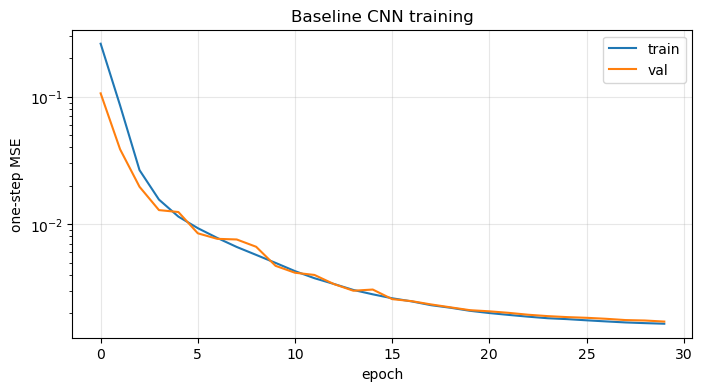

In [4]:
baseline = make_cnn_dynamics(hidden_channels=64, depth=4, zero_init_output=False)

hist_baseline = train_derivative_model(
    baseline,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    device=DEVICE,
    checkpoint_path=CKPT_DIR / "swe2d_cnn_baseline_derivative.pt",
    print_every=5,
    use_amp=False,
)

plt.figure(figsize=(8, 4))
plt.semilogy(hist_baseline.train_loss, label="train")
plt.semilogy(hist_baseline.val_loss, label="val")
plt.xlabel("epoch")
plt.ylabel("one-step MSE")
plt.title("Baseline CNN training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Train energy-projected CNN

epoch=0001 deriv_train=0.306861 deriv_val=0.0949736 best=0.0949736
epoch=0005 deriv_train=0.0107746 deriv_val=0.0103583 best=0.0103583
epoch=0010 deriv_train=0.00444194 deriv_val=0.00436759 best=0.00436759
epoch=0015 deriv_train=0.00275596 deriv_val=0.00275065 best=0.00275065
epoch=0020 deriv_train=0.00206268 deriv_val=0.00211358 best=0.00211358
epoch=0025 deriv_train=0.00175511 deriv_val=0.00181646 best=0.00181646
epoch=0030 deriv_train=0.00161348 deriv_val=0.0016888 best=0.0016888


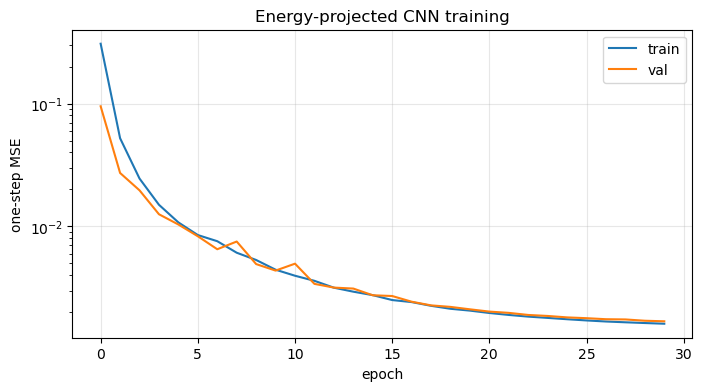

In [5]:
stable = make_energy_projected_cnn(
    hidden_channels=64,
    depth=4,
    gravity=cfg.gravity,
    depth_water=cfg.depth,
    alpha=1e-5,
    zero_init_output=False,
)

hist_stable = train_derivative_model(
    stable,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    device=DEVICE,
    checkpoint_path=CKPT_DIR / "swe2d_cnn_energy_projected_derivative.pt",
    print_every=5,
    use_amp=False,
)

plt.figure(figsize=(8, 4))
plt.semilogy(hist_stable.train_loss, label="train")
plt.semilogy(hist_stable.val_loss, label="val")
plt.xlabel("epoch")
plt.ylabel("one-step MSE")
plt.title("Energy-projected CNN training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Rollout evaluation on one test trajectory

In [6]:
test_id = 0
true_rollout = test_traj[test_id]
state0 = true_rollout[0]

baseline_rollout = rollout_torch_dynamics(
    baseline, state0, steps=STEPS, dt=cfg.dt, device=DEVICE
)
stable_rollout = rollout_torch_dynamics(
    stable, state0, steps=STEPS, dt=cfg.dt, device=DEVICE
)

rmse_baseline = compute_rmse(true_rollout, baseline_rollout)
rmse_stable = compute_rmse(true_rollout, stable_rollout)
t = np.arange(STEPS + 1) * cfg.dt

summary = {
    "baseline": summarize_rollout(true_rollout, baseline_rollout, cfg).as_dict(),
    "energy_projected": summarize_rollout(true_rollout, stable_rollout, cfg).as_dict(),
    "projection": energy_projection_stats(stable, stable_rollout, device=DEVICE),
}
summary_path = RESULTS_DIR / "swe2d_learning_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
print("saved:", summary_path)

{
  "baseline": {
    "final_rmse": 0.03248705714941025,
    "mean_rmse": 0.016049843281507492,
    "max_rmse": 0.03248705714941025,
    "true_energy_start": 0.00107477861456573,
    "true_energy_end": 0.0010482498910278082,
    "pred_energy_start": 0.00107477861456573,
    "pred_energy_end": 0.0018141460604965687,
    "true_mass_start": 1.1641532182693481e-10,
    "true_mass_end": -2.3283064365386963e-10,
    "pred_mass_start": 1.1641532182693481e-10,
    "pred_mass_end": 0.004575351253151894
  },
  "energy_projected": {
    "final_rmse": 0.026807263493537903,
    "mean_rmse": 0.016816237941384315,
    "max_rmse": 0.026807263493537903,
    "true_energy_start": 0.00107477861456573,
    "true_energy_end": 0.0010482498910278082,
    "pred_energy_start": 0.00107477861456573,
    "pred_energy_end": 0.0011645469348877668,
    "true_mass_start": 1.1641532182693481e-10,
    "true_mass_end": -2.3283064365386963e-10,
    "pred_mass_start": 1.1641532182693481e-10,
    "pred_mass_end": -0.0007171

## Plot rollout error

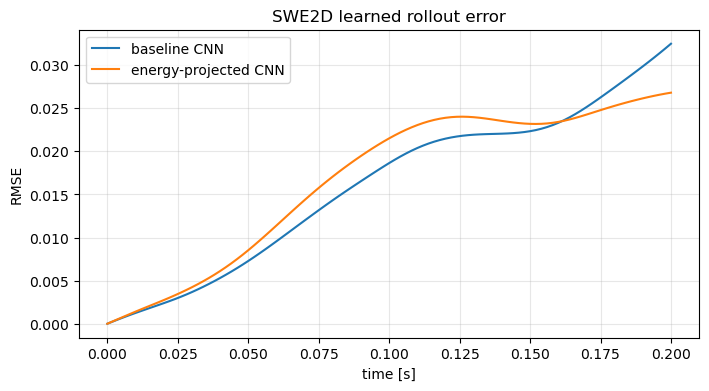

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(t, rmse_baseline, label="baseline CNN")
plt.plot(t, rmse_stable, label="energy-projected CNN")
plt.xlabel("time [s]")
plt.ylabel("RMSE")
plt.title("SWE2D learned rollout error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Plot energy and mass

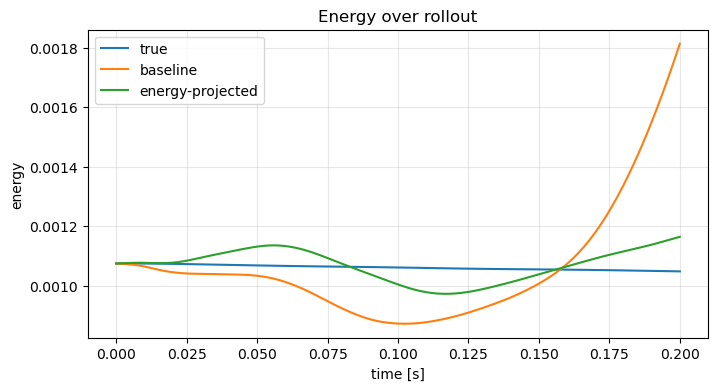

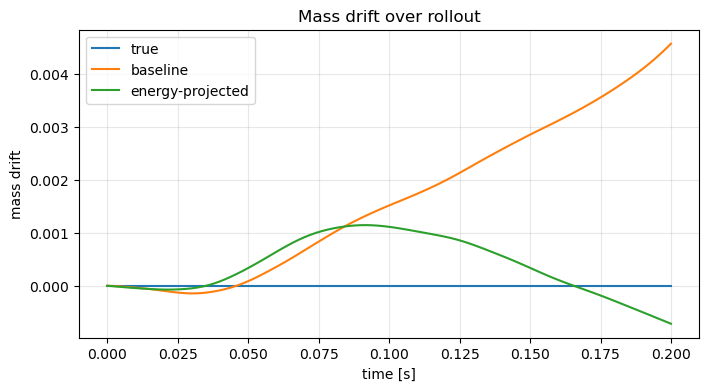

In [8]:
def series_energy_mass(traj):
    energy = np.array([compute_energy(s, cfg) for s in traj])
    mass = np.array([compute_mass(s, cfg) for s in traj])
    return energy, mass

e_true, m_true = series_energy_mass(true_rollout)
e_base, m_base = series_energy_mass(baseline_rollout)
e_stab, m_stab = series_energy_mass(stable_rollout)

plt.figure(figsize=(8, 4))
plt.plot(t, e_true, label="true")
plt.plot(t, e_base, label="baseline")
plt.plot(t, e_stab, label="energy-projected")
plt.xlabel("time [s]")
plt.ylabel("energy")
plt.title("Energy over rollout")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, m_true - m_true[0], label="true")
plt.plot(t, m_base - m_base[0], label="baseline")
plt.plot(t, m_stab - m_stab[0], label="energy-projected")
plt.xlabel("time [s]")
plt.ylabel("mass drift")
plt.title("Mass drift over rollout")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Side-by-side animation

saved: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/results/swe2d_true_vs_baseline_cnn.gif
saved: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/results/swe2d_true_vs_energy_projected_cnn.gif


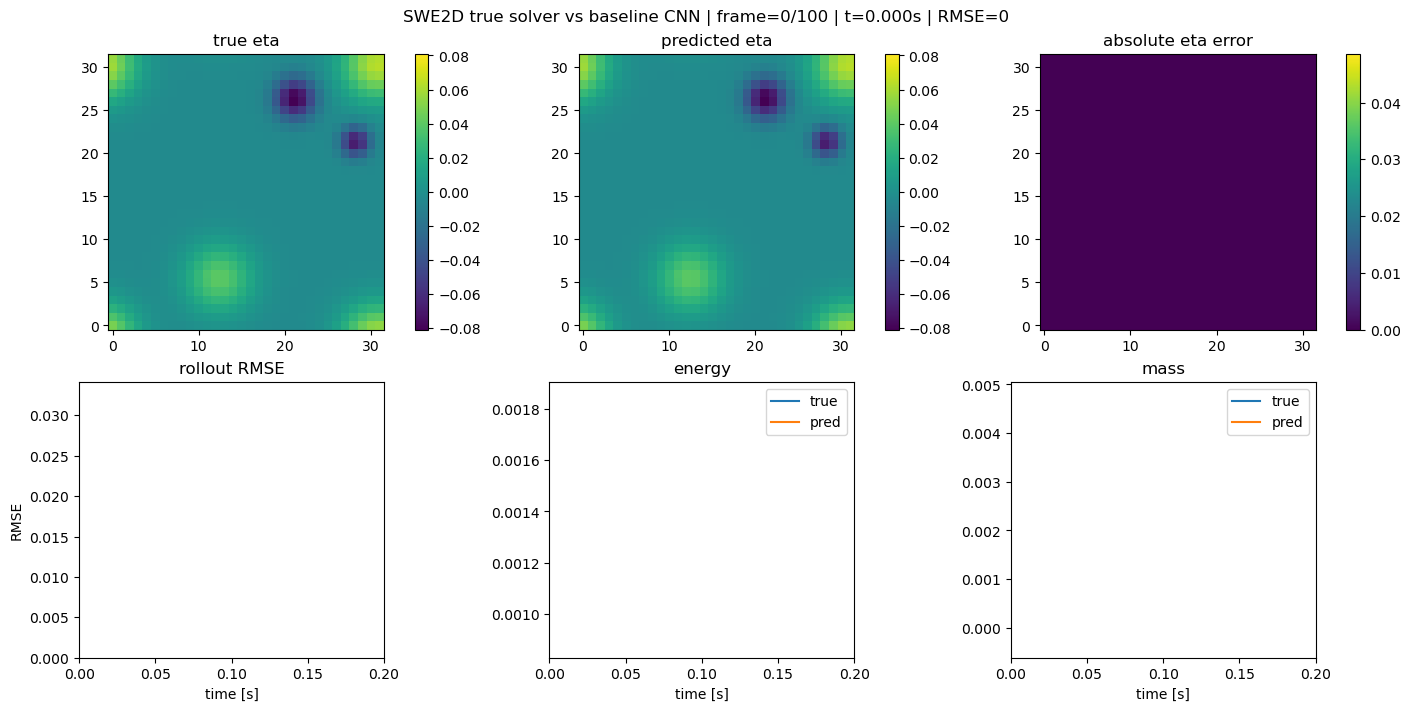

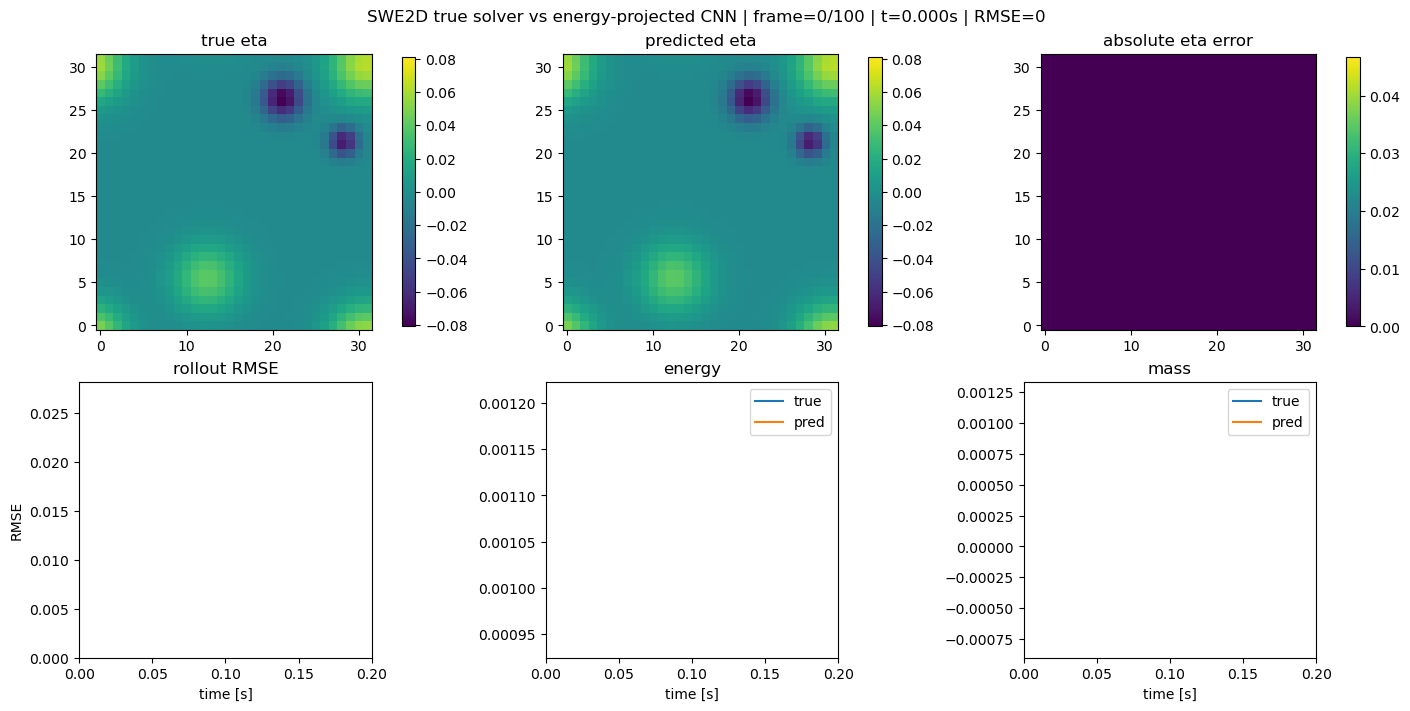

In [9]:
anim_baseline = animate_eta_comparison(
    true_rollout,
    baseline_rollout,
    cfg,
    interval_ms=40,
    title="SWE2D true solver vs baseline CNN",
)
baseline_gif = RESULTS_DIR / "swe2d_true_vs_baseline_cnn.gif"
save_gif(anim_baseline, baseline_gif, fps=25)
print("saved:", baseline_gif)

anim_stable = animate_eta_comparison(
    true_rollout,
    stable_rollout,
    cfg,
    interval_ms=40,
    title="SWE2D true solver vs energy-projected CNN",
)
stable_gif = RESULTS_DIR / "swe2d_true_vs_energy_projected_cnn.gif"
save_gif(anim_stable, stable_gif, fps=25)
print("saved:", stable_gif)